In [1]:
# --- Markdown: ## 1. Imports and Setup ---
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Add the CMD directory to the Python path so it can find background.py
cmd_dir = os.path.abspath('../CMD')

if cmd_dir not in sys.path:
    sys.path.append(cmd_dir)
    print(f"Added to path: {cmd_dir}")

try:
    from background import Cmd
    print("✅ Successfully imported Cmd from background.py!")
except ModuleNotFoundError:
    print(f"❌ ERROR: Could not find 'background.py' inside {cmd_dir}")
    print(f"Current Notebook Working Directory: {os.getcwd()}")
    print("Please check your folder structure!")

# Import the CoolTrack engine and math functions
from cooltrack.cooltrack import SemiAnalyticalCoolTrack, softplus_piecewise, generalized_sigmoid, sloped_sigmoid
from cooltrack.data_loader import load_grid

from cooltrack.constants import INDEPENDENT_DIMS as independent_dims

if cmd_dir not in sys.path:
    sys.path.append(cmd_dir)
    print(f"Added to path: {cmd_dir}")


# A&A Publication Formatting
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix', 
    'font.size': 11,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'figure.facecolor': 'white'
})

Added to path: /travail/cwilkinson/cooltrack/CMD
✅ Successfully imported Cmd from background.py!


In [2]:
import h5py
import os

def print_hdf5_tree(h5_path, max_models_to_show=2):
    """
    Prints a beautifully formatted tree of the HDF5 file structure,
    including all Groups, Datasets, and Attributes.
    """
    if not os.path.exists(h5_path):
        print(f"❌ File not found: {h5_path}")
        return
        
    file_size_mb = os.path.getsize(h5_path) / (1024 * 1024)
    print(f"🗄️ HDF5 File: {h5_path} ({file_size_mb:.1f} MB)")
    print("=" * 60)
    
    def print_attributes(obj, indent):
        """Helper to neatly print attributes attached to a group/dataset."""
        for attr_name, attr_val in obj.attrs.items():
            val_str = str(attr_val)
            if len(val_str) > 60:
                val_str = val_str[:57] + "..."
            print(f"{indent}  🏷️ {attr_name}: {val_str}")

    def print_structure(name, obj):
        """Recursive callback for h5py's visititems."""
        depth = name.count('/') + 1 
        indent = "    " * depth
        item_name = name.split('/')[-1]
        
        if isinstance(obj, h5py.Group):
            print(f"{indent}📁 {item_name}/")
            print_attributes(obj, indent)
                
        elif isinstance(obj, h5py.Dataset):
            print(f"{indent}📄 {item_name}  |  Shape: {obj.shape}  |  Type: {obj.dtype}")
            print_attributes(obj, indent)

    # Open the file and trigger the recursive print
    with h5py.File(h5_path, "r") as h5f:
        model_keys = list(h5f.keys())
        print(f"📦 Total Models Stored: {len(model_keys)}\n")
        
        # Iterate through just the first few models
        for i, model_id in enumerate(model_keys[:max_models_to_show]):
            print(f"🪐 {model_id}/")
            
            # Print attributes attached directly to the root model folder
            print_attributes(h5f[model_id], "")
            
            # Recursively walk through everything inside this model
            h5f[model_id].visititems(print_structure)
            
            print("-" * 60)

# --- RUN IT ---
H5_FILE = "../../exoweave/outputs/master_grid_cooltrack.h5"
print_hdf5_tree(H5_FILE)

🗄️ HDF5 File: ../../exoweave/outputs/master_grid_cooltrack.h5 (2792.9 MB)
📦 Total Models Stored: 21378

🪐 model_00099/
    📁 cooling_metrics/
      🏷️ L_int: 1.2844592088092144e+21
      🏷️ ds_dt: -3.8352197839890315e-09
      🏷️ dt_ds: -260741249.86910003
    📁 interior_raw/
      🏷️ M_total: 1.0402583374198634e+26
      🏷️ R_total: 38812579.46810364
      🏷️ dt_ds_total: -260741249.86910003
        📄 S  |  Shape: (135,)  |  Type: float64
    📁 parameters/
      🏷️ Met: 1.3985920943425323
      🏷️ T_eff: 1045.951507312925
      🏷️ T_int: 1045.8958160066943
      🏷️ T_int_input_dial: 1048.6818897398825
      🏷️ T_irr: 126.35337303716878
      🏷️ core_mass_earth: 14.345358246466358
      🏷️ f_sed: {"Fe": 4.756485328365052, "Mg2SiO4": 4.756485328365052, "...
      🏷️ kzz: 1.6241569776155926
      🏷️ mass: 0.05015248767585593
      🏷️ true_mass_Mjup: 0.05480825285714446
    📁 photometry/
        📁 bands/
            📁 2MASS_2MASS.H/
              🏷️ flux_W_m2_um: 18474.421891936883
      

In [3]:
GRID_PATH = "../../exoweave/outputs/master_grid_cooltrack.h5" 
#GRID_PATH = "../../exoweave/outputs/master_grid_cloudless_cooltrack.h5"


print("Loading full unstructured grid...")
df_grid = load_grid(GRID_PATH, use_cache=False)

# Initialize the Semi-Analytical Engine
# (Passing None for initial conditions since we will manually override T_start later)
engine = SemiAnalyticalCoolTrack(
    grid_df=df_grid, 
    initial_conditions_model=None, 
    independent_dims=independent_dims, 
    bandwidth=0.5
)
print(f"✅ Engine initialized with {len(engine.grid_df)} valid atmospheric models.")

2026-05-04 16:33:37,449 - INFO - ⏳ Parquet cache not found or disabled. Running parallel HDF5 extraction...
2026-05-04 16:33:37,450 - INFO - Loading Exoweave HDF5 file: ../../exoweave/outputs/master_grid_cooltrack.h5...


Loading full unstructured grid...


2026-05-04 16:33:38,300 - INFO - Spinning up 47 workers to read HDF5 across network...
Reading HDF5 Chunks: 100%|██████████| 190/190 [00:18<00:00, 10.49it/s]


Extracted 21378 models from Exoweave HDF5 file.


2026-05-04 16:34:09,253 - INFO - ✅ Exoweave Grid loaded and mapped successfully. Final shape: (20999, 301)


✅ Engine initialized with 20999 valid atmospheric models.


In [4]:
# --- Markdown: ## 3. Define Target Planet & Extract Surrogates ---
# Let's test a massive 10 Jupiter-mass brown dwarf/planet
target_planet = {
    'mass_Mj': 5.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 4.0,
    'f_sed_volatile': 6.0,
    'kzz': 8.0, 
    'T_irr': 0.0
}

# The specific bands we want to fit and plot
photometry_bands = [
 'log_Keck/NIRC2.J',
 'log_Keck/NIRC2.Ks',
 'log_Keck/NIRC2.Ks',
]

print(f"Extracting surrogate fits for: {target_planet}...")
fits = engine.fit_surrogate(target_planet, photometry_bands, photometry_method='bspline')

print("✅ Fits extracted successfully!")
print(f"   -> Thermodynamics R2 : {fits['r2_S']:.3f}")
print(f"   -> Cooling Rate R2   : {fits['r2_tau']:.3f}")
print(f"   -> Radius R2         : {fits['r2_R']:.3f}")

Extracting surrogate fits for: {'mass_Mj': 5.0, 'Met': 0.0, 'core': 10.0, 'f_sed_refractory': 4.0, 'f_sed_volatile': 6.0, 'kzz': 8.0, 'T_irr': 0.0}...
Radius fit successful with R²=0.977
Radius fit parameters: [11.45898644  1.25873182 -0.18245737 10.14990315  5.        ]
✅ Fits extracted successfully!
   -> Thermodynamics R2 : 0.976
   -> Cooling Rate R2   : 0.922
   -> Radius R2         : 0.977


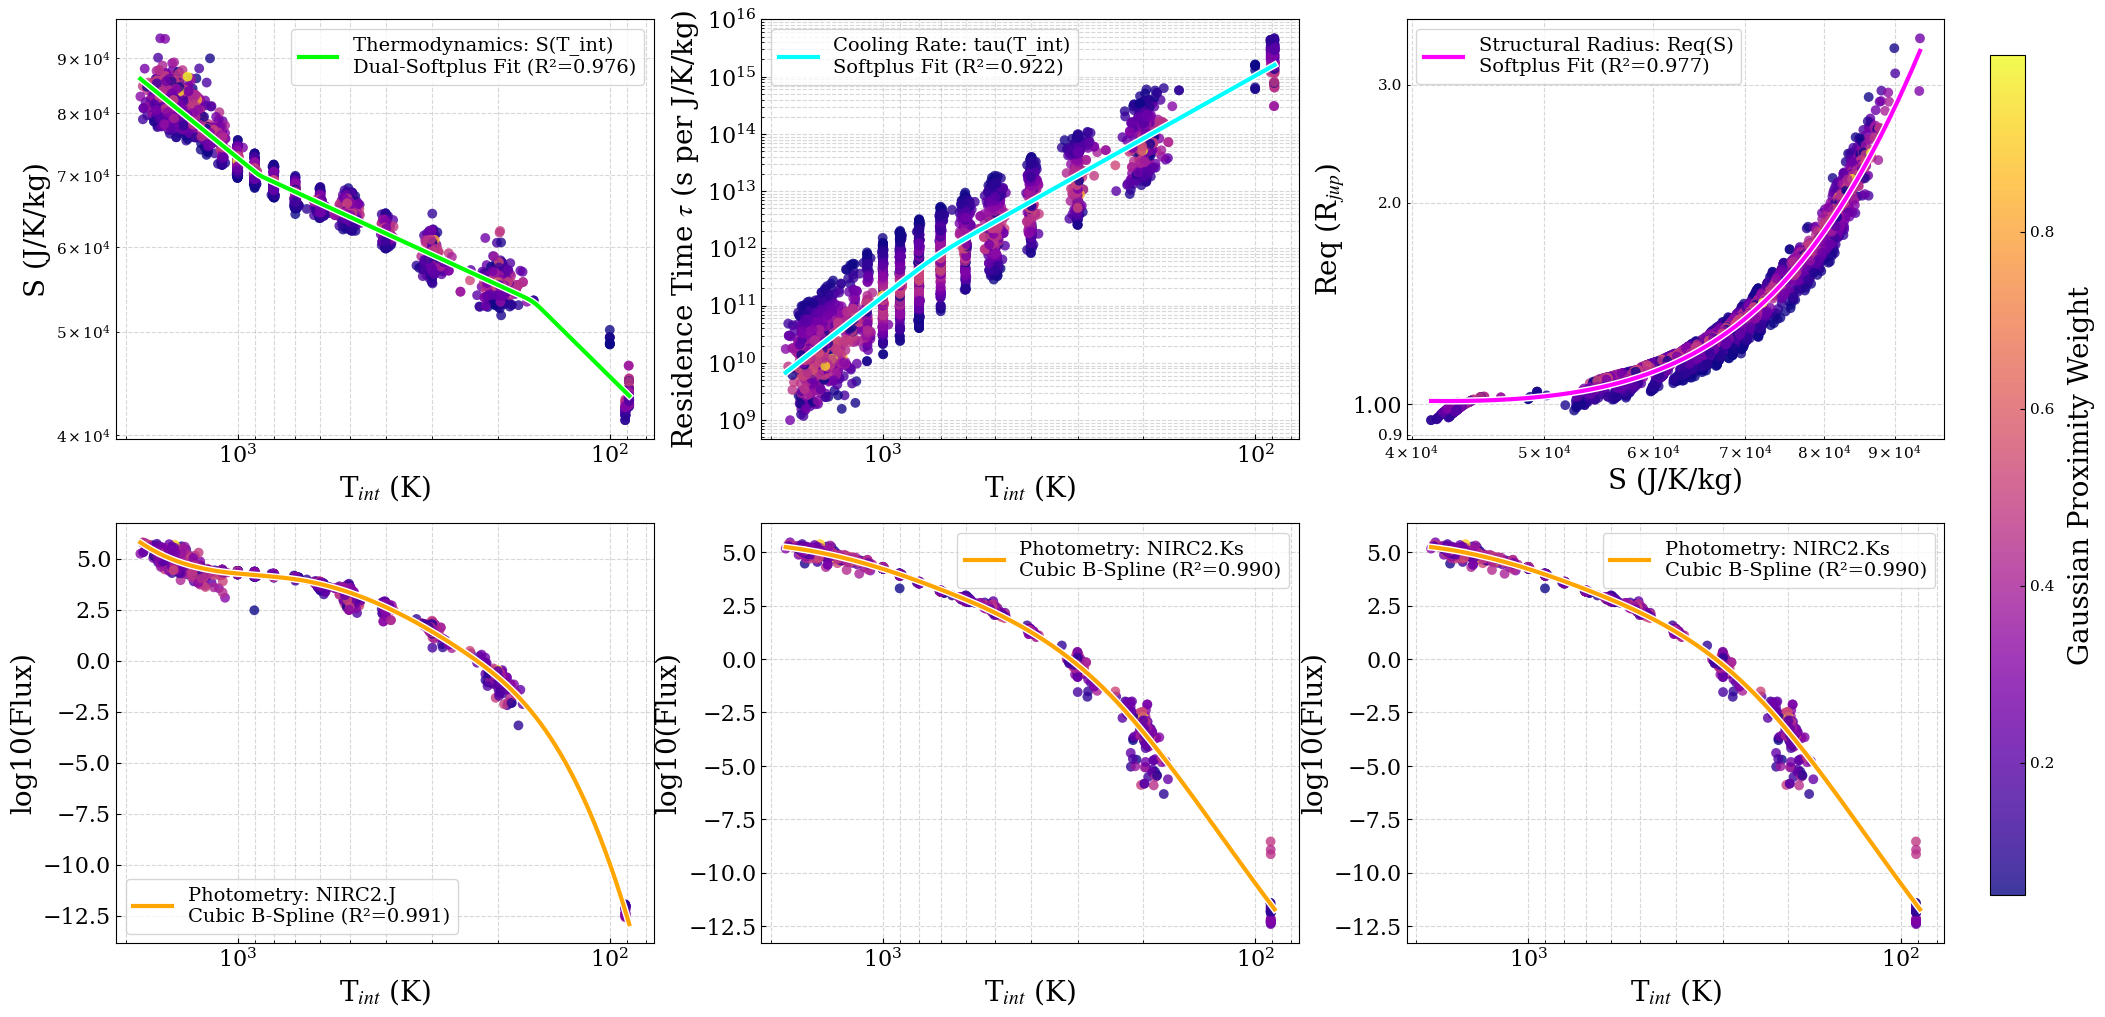

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from cooltrack.cooltrack import softplus_piecewise, dual_softplus_piecewise, quadratic_sigmoid, sloped_sigmoid
from scipy.interpolate import BSpline
from matplotlib.ticker import ScalarFormatter

# --- Markdown: ## 4. Visualize All Surrogates ---
track = fits['track_data']

# We will color the points by their Gaussian Weight to see what the fitter "cared" about
weights = track['weight'].values
scatter_kwargs = {'c': weights, 'cmap': 'plasma', 's': 50, 'edgecolors': 'none', 'alpha': 0.8, 'zorder': 2}
stroke = [pe.withStroke(linewidth=5, foreground='white')]

# Make the figure slightly wider to accommodate the new colorbar
fig, axes = plt.subplots(2, 3, figsize=(23, 12))
axes = axes.flatten()

# Pre-calculate raw values for the scatter plots
T_int_raw = np.exp(track['ln_Tint'])
S_raw = np.exp(track['ln_S'])
tau_raw = np.exp(track['ln_tau'])
Req_raw = np.exp(track['ln_Req'])

# Common smooth axes for plotting curves
x_Tint_smooth = np.linspace(track['ln_Tint'].min(), track['ln_Tint'].max(), 200)

# ---------------------------------------------------------
# Plot 1: Thermodynamics (Adaptive: Dual-Softplus, Softplus, or Linear)
# ---------------------------------------------------------
ax = axes[0]
sc = ax.scatter(T_int_raw, S_raw, **scatter_kwargs) # Save 'sc' for the colorbar later

# --- THE FIX: Dynamically handle the 3-segment Dual-Softplus ---
if fits.get('method_S') == 'dual_softplus':
    y_S_smooth = dual_softplus_piecewise(x_Tint_smooth, *fits['popt_S'])
    fit_type_S = "Dual-Softplus"
elif fits.get('method_S') == 'softplus':
    y_S_smooth = softplus_piecewise(x_Tint_smooth, *fits['popt_S'])
    fit_type_S = "Softplus"
else:
    y_S_smooth = fits['C'] * x_Tint_smooth + fits['D']
    fit_type_S = "Linear"

# Combine title and R2 into the legend label
label_1 = f"Thermodynamics: S(T_int)\n{fit_type_S} Fit (R²={fits['r2_S']:.3f})"
ax.plot(np.exp(x_Tint_smooth), np.exp(y_S_smooth), color='lime', lw=3, path_effects=stroke, label=label_1)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'T$_{int}$ (K)', fontsize=20)
ax.set_ylabel('S (J/K/kg)', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14)
ax.grid(True, which="both", ls='--', alpha=0.5)
ax.invert_xaxis()

# ---------------------------------------------------------
# Plot 2: Cooling Rate (Adaptive: Softplus or Linear)
# ---------------------------------------------------------
ax = axes[1]
ax.scatter(T_int_raw, tau_raw, **scatter_kwargs)

if fits.get('method_tau') == 'softplus':
    y_tau_smooth = softplus_piecewise(x_Tint_smooth, *fits['popt_tau'])
    fit_type_tau = "Softplus"
else:
    y_tau_smooth = fits['A'] * x_Tint_smooth + fits['B']
    fit_type_tau = "Linear"

label_2 = f"Cooling Rate: tau(T_int)\n{fit_type_tau} Fit (R²={fits['r2_tau']:.3f})"
ax.plot(np.exp(x_Tint_smooth), np.exp(y_tau_smooth), color='cyan', lw=3, path_effects=stroke, label=label_2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'T$_{int}$ (K)', fontsize=20)
ax.set_ylabel(r'Residence Time $\tau$ (s per J/K/kg)', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14)
ax.grid(True, which="both", ls='--', alpha=0.5)
ax.invert_xaxis()

# ---------------------------------------------------------
# Plot 3: Structural Radius (Softplus in S Space)
# ---------------------------------------------------------
ax = axes[2]
ax.scatter(S_raw, Req_raw, **scatter_kwargs)

# We use the smooth entropy array derived from the thermodynamic adaptive bounds
x_S_smooth = np.linspace(track['ln_S'].min(), track['ln_S'].max(), 200)
y_R_smooth = softplus_piecewise(x_S_smooth, *fits['popt_R'])

label_3 = f"Structural Radius: Req(S)\nSoftplus Fit (R²={fits['r2_R']:.3f})"
ax.plot(np.exp(x_S_smooth), np.exp(y_R_smooth), color='magenta', lw=3, path_effects=stroke, label=label_3)

ax.set_xscale('log')
ax.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(formatter)

# Standardized font sizes to match the rest of the dashboard
ax.set_xlabel('S (J/K/kg)', fontsize=20)
ax.set_ylabel(r'Req (R$_{jup}$)', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14)
ax.grid(True, which="both", ls='--', alpha=0.5)

# ---------------------------------------------------------
# Plots 4, 5, 6: Photometry (Adaptive Evaluation)
# ---------------------------------------------------------
tol_tirr = 10.0
target_tirr_raw = target_planet.get('T_irr', 0.0)

# Filter the raw points for visual clarity on the 2D plot
phot_track = track[np.abs(track['T_irr'] - target_tirr_raw) <= tol_tirr].copy()

target_tirr_scaled = target_tirr_raw / 100.0
X_query_phot = np.vstack([x_Tint_smooth, np.full_like(x_Tint_smooth, target_tirr_scaled)]).T

for i, band in enumerate(photometry_bands):
    ax = axes[i + 3]
    
    clean_track = phot_track.dropna(subset=[band])
    filter_name = band.split('/')[-1]
    
    # Check if the fit exists for this band
    if clean_track.empty or fits['photometry'].get(band) is None:
        ax.text(0.5, 0.5, "No Data / Fit Failed", ha='center', va='center', transform=ax.transAxes, fontsize=14)
        continue
        
    # Scatter plot against Tint (exponential of ln_Tint)
    ax.scatter(np.exp(clean_track['ln_Tint']), clean_track[band], c=clean_track['weight'], cmap='plasma', 
               s=50, edgecolors='none', alpha=0.8, zorder=2)
    
    # --- Adaptive Prediction based on Fit Method ---
    phot_params = fits['photometry'][band]
    r2_F = phot_params['r2']

    if phot_params['method'] == 'bspline':   
        spl = BSpline(phot_params['t_knots'], phot_params['popt'], 3, extrapolate=True)
        y_F_smooth = spl(x_Tint_smooth)
        label_text = f"Photometry: {filter_name}\nCubic B-Spline (R²={r2_F:.3f})"
    elif phot_params['method'] == 'quadratic_sigmoid':   
        y_F_smooth = quadratic_sigmoid(x_Tint_smooth, *phot_params['popt']) 
        label_text = f"Photometry: {filter_name}\nQuadratic Sigmoid (R²={r2_F:.3f})"
    elif phot_params['method'] == 'sigmoid':   
        y_F_smooth = sloped_sigmoid(x_Tint_smooth, *phot_params['popt']) 
        label_text = f"Photometry: {filter_name}\nSigmoid Fit (R²={r2_F:.3f})"
    elif phot_params['method'] == 'locallinear':
        tree_model = phot_params['model']
        y_F_smooth = tree_model.predict(X_query_phot)
        label_text = f"Photometry: {filter_name}\nKD-Tree Fit (R²={r2_F:.3f})"
    else:
        y_F_smooth = softplus_piecewise(x_Tint_smooth, *phot_params['popt'])
        label_text = f"Photometry: {filter_name}\nSoftplus Fit (R²={r2_F:.3f})"
    
    # Plot the smooth predicted track
    ax.plot(np.exp(x_Tint_smooth), y_F_smooth, color='orange', lw=3, path_effects=stroke, label=label_text)
    
    ax.set_xscale('log')
    ax.set_xlabel(r'T$_{int}$ (K)', fontsize=20)
    ax.set_ylabel('log10(Flux)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(fontsize=14)
    ax.grid(True, which="both", ls='--', alpha=0.5)
    ax.invert_xaxis()

# --- Add Global Colorbar for Coherence ---
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Gaussian Proximity Weight", fontsize=20, labelpad=10)

plt.show()

In [6]:
np.exp(7.5)

np.float64(1808.0424144560632)

In [7]:
df_grid.columns

Index(['mass', 'T_int', 'T_int_input_dial', 'T_irr', 'T_eff', 'Met', 'core',
       'f_sed_refractory', 'f_sed_volatile', 'kzz',
       ...
       'log_MKO/MIRSI.7_7', 'log_MKO/MIRSI.8_7', 'log_MKO/MIRSI.9_7',
       'log_MKO/MIRSI.N', 'log_MKO/MIRSI.11_7', 'log_MKO/MIRSI.12_282',
       'log_MKO/MIRSI.12_33', 'log_MKO/MIRSI.18', 'log_MKO/MIRSI.20',
       'log_MKO/MIRSI.24'],
      dtype='object', length=301)

2026-05-04 16:36:17,575 - INFO - Loaded initial condition interpolators from 4 files.


✅ Engine initialized with 20999 valid atmospheric models.
Fetching filters for Blackbody integration...
Radius fit successful with R²=0.969
Radius fit parameters: [11.47429547  1.25873182 -0.17319537 10.22625556  5.        ]


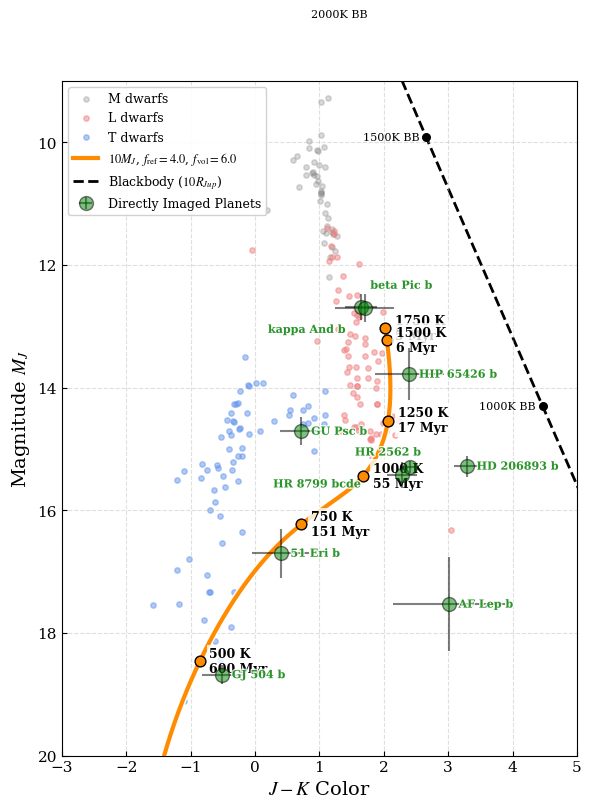

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import urllib.request
from io import StringIO
from cooltrack.initial_conditions import InitialConditions
from scipy.ndimage import gaussian_filter1d

# =====================================================================
# Setting the engine
# =====================================================================

AGE_DATA_PATH = "../data/age_data" 
init_conds = InitialConditions(age_data_path=AGE_DATA_PATH)

engine = SemiAnalyticalCoolTrack(
    grid_df=df_grid, 
    initial_conditions_model=init_conds, 
    independent_dims=independent_dims, 
    bandwidth=0.5,
)

print(f"✅ Engine initialized with {len(engine.grid_df)} valid atmospheric models.")

# =====================================================================
# MAGNITUDE CONVERSION CONSTANTS & FUNCTION
# =====================================================================
R_J_M = 7.1492e7
PC_10_M = 3.08567758e17
SCALE_FACTOR_LOG = 2 * np.log10(R_J_M / PC_10_M) 

# Keck/NIRC2 Vega Zero Points (True flux at Earth, do not scale to 10pc!)
VEGA_FLUX_LOG = {
    'log_Keck/NIRC2.J': np.log10(3.129e-9), 
    'log_Keck/NIRC2.Ks': np.log10(4.3277e-10)
}

def surface_flux_to_abs_mag(log_flux_surf, radius_rj, band):
    """Converts log10 surface flux to Absolute Vega Magnitude at 10 pc."""
    log_flux_10pc = log_flux_surf + 2 * np.log10(radius_rj) + SCALE_FACTOR_LOG
    return -2.5 * (log_flux_10pc - VEGA_FLUX_LOG[band])

# =====================================================================
# BLACKBODY PHYSICS SETUP
# =====================================================================
print("Fetching filters for Blackbody integration...")
def get_filter(filter_id):
    url = f"https://svo2.cab.inta-csic.es/theory/fps/getdata.php?format=ascii&id={filter_id}"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    response = urllib.request.urlopen(req)
    parsed = np.genfromtxt(StringIO(response.read().decode('utf-8')))
    return parsed[:, 0] * 1e-4, parsed[:, 1] 

filt_wav_j, filt_trans_j = get_filter("Keck/NIRC2.J")
filt_wav_k, filt_trans_k = get_filter("Keck/NIRC2.Ks")

def planck_surface_flux(wav_um, T):
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23
    wav_m = wav_um * 1e-6
    intensity = (2 * h * c**2 / wav_m**5) / (np.exp(h * c / (wav_m * k * T)) - 1)
    return np.pi * intensity * 1e-6

def integrate_bb_band(wav_um, trans, T):
    bb_flux = planck_surface_flux(wav_um, T)
    num = np.trapezoid(bb_flux * trans * wav_um, wav_um)
    den = np.trapezoid(trans * wav_um, wav_um)
    return num / den

# =====================================================================
# PLOTTING ROUTINE
# =====================================================================
cmd_bg = Cmd(datapath='../CMD/data/') 
cmd_bg._dupuy() 

fig, ax = plt.subplots(figsize=(6, 7.5))

# Plot Background M, L, T Dwarfs
ax.scatter(cmd_bg.MD['magJ'] - cmd_bg.MD['magK'], cmd_bg.MD['magJ'], color='gray', alpha=0.3, s=15, label='M dwarfs')
ax.scatter(cmd_bg.LD['magJ'] - cmd_bg.LD['magK'], cmd_bg.LD['magJ'], color='lightcoral', alpha=0.5, s=15, label='L dwarfs')
ax.scatter(cmd_bg.TD['magJ'] - cmd_bg.TD['magK'], cmd_bg.TD['magJ'], color='cornflowerblue', alpha=0.5, s=15, label='T dwarfs')

# --- Target Bands ---
band_J = 'log_Keck/NIRC2.J' 
band_K = 'log_Keck/NIRC2.Ks' 

# 1. Explicitly define the target planet
target_planet = {
    'mass_Mj': 10.0, 
    'f_sed_refractory': 4.0,  
    'f_sed_volatile': 6.0,    
    'Met': 0.0, 
    'core': 10.0, 
    'kzz': 8.0,
    'T_irr': 100
}

# 2. Extract the fits
fits_fsed1 = engine.fit_surrogate(
    target_planet, 
    photometry_bands=[band_J, band_K],
    photometry_method='bspline' 
)

# 3. Start exactly at the top of the available grid data so the age syncs up
max_grid_temp = np.exp(fits_fsed1['track_data']['ln_Tint'].max())
evol = engine.evolve(fits_fsed1, T_start_override=None, start_type=19)

evol = evol[evol['age_yr'] >= 5*1e6]

# =====================================================================
# 4. CALCULATE MAGNITUDES AND ANALYTICAL ERRORS
# =====================================================================
from matplotlib.patches import Ellipse

# --- Extract standard deviations from the Monte Carlo bounds ---
sigma_logJ = (evol[f'{band_J}_upper'] - evol[f'{band_J}_lower']) / 2.0
sigma_logK = (evol[f'{band_K}_upper'] - evol[f'{band_K}_lower']) / 2.0
sigma_R = (evol['Req_Rj_upper'] - evol['Req_Rj_lower']) / 2.0

def get_mag_and_err(log_flux, sigma_logf, radius, sigma_r, band):
    # Median Mag
    log_flux_10pc = log_flux + 2 * np.log10(radius) + SCALE_FACTOR_LOG
    mag = -2.5 * (log_flux_10pc - VEGA_FLUX_LOG[band])
    
    # Analytical Error Propagation 
    term_flux = (-2.5 * sigma_logf)**2
    term_radius = (-5.0 / (radius * np.log(10)) * sigma_r)**2
    mag_err = np.sqrt(term_flux + term_radius)
    
    return mag, mag_err

# Calculate Absolute Magnitudes and Errors
mJ, sigMJ = get_mag_and_err(evol[band_J], sigma_logJ, evol['Req_Rj'], sigma_R, band_J)
mK, sigMK = get_mag_and_err(evol[band_K], sigma_logK, evol['Req_Rj'], sigma_R, band_K)

# Combined Median Color (X-axis)
color_JK = mJ - mK

# Quadratic sum of J and K errors for the Color Error (X-axis radius)
sigColor = np.sqrt(sigMJ**2 + sigMK**2)

# =====================================================================
# Stamp Error Ellipses (Swept Ribbon)
# =====================================================================
#for x, y, sx, sy in zip(color_JK, mJ, sigColor, sigMJ):
    # Width is 2*x_radius, Height is 2*y_radius
    #ell = Ellipse(xy=(x, y), width=2*sx, height=2*sy, 
    #              facecolor='darkorange', alpha=0.05, lw=0, zorder=4)
    #ax.add_patch(ell)

# Plot the Median Spine
stroke = [pe.withStroke(linewidth=5, foreground='white')]
ax.plot(color_JK, mJ, color='darkorange', lw=3, path_effects=stroke, zorder=6,
        label=r'$10 M_J$, $f_{\rm ref}=4.0$, $f_{\rm vol}=6.0$')

# =====================================================================
# 5. ANNOTATIONS & MARKERS
# =====================================================================
# Add Temperature & Age Annotations along the track
marker_temps = [1500, 1250, 1000, 750, 500]
for T_mark in marker_temps:
    idx = (np.abs(evol['T_int'] - T_mark)).argmin()
    x_pt = color_JK.iloc[idx]
    y_pt = mJ.iloc[idx]  # FIXED: Changed mag_J to mJ
    age_myr = evol['age_yr'].iloc[idx] / 1e6
    
    ax.scatter(x_pt, y_pt, color='darkorange', edgecolor='black', s=60, zorder=7)
    ax.text(x_pt + 0.15, y_pt, f"{T_mark} K\n{age_myr:.0f} Myr", fontsize=9, va='center', ha='left', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2), zorder=8)

# =====================================================================
# ADD BLACKBODY CURVE TO PLOT
# =====================================================================
bb_temps = np.linspace(2500, 500, 50)
bb_mag_J, bb_mag_K = [], []
bb_radius = 10.0 # 10.0 R_J reference size

for T in bb_temps:
    flux_J = integrate_bb_band(filt_wav_j, filt_trans_j, T)
    flux_K = integrate_bb_band(filt_wav_k, filt_trans_k, T)
    
    m_J = surface_flux_to_abs_mag(np.log10(flux_J), bb_radius, band_J)
    m_K = surface_flux_to_abs_mag(np.log10(flux_K), bb_radius, band_K)
    
    bb_mag_J.append(m_J)
    bb_mag_K.append(m_K)

bb_mag_J = np.array(bb_mag_J)
bb_color_JK = np.array(bb_mag_J) - np.array(bb_mag_K)

ax.plot(bb_color_JK, bb_mag_J, color='black', lw=2, ls='--', zorder=1, label=r'Blackbody ($10 R_{Jup}$)')

# Annotate Blackbody temperatures
for T_mark in [2000, 1500, 1000]:
    idx = (np.abs(bb_temps - T_mark)).argmin()
    ax.scatter(bb_color_JK[idx], bb_mag_J[idx], color='black', s=30, zorder=2)
    ax.text(bb_color_JK[idx] - 0.1, bb_mag_J[idx], f"{T_mark}K BB", fontsize=8, ha='right', va='center')


# =====================================================================
# ADD KNOWN OBJECTS TO PLOT
# =====================================================================
# Directly imaged planets
imaged_planets = {
    '51 Eri b':    {'J': 16.70, 'J_err': 0.40, 'K': 16.30, 'K_err': 0.19},
    'GJ 504 b':    {'J': 18.68, 'J_err': 0.15, 'K': 19.19, 'K_err': 0.28},
    'HR 8799 bcde':{'J': 15.42, 'J_err': 0.21, 'K': 13.14, 'K_err': 0.10}, 
    'beta Pic b':  {'J': 12.68, 'J_err': 0.21, 'K': 11.04, 'K_err': 0.13},
    'kappa And b': {'J': 12.70, 'J_err': 0.23, 'K': 11.00, 'K_err': 0.40},
    'GU Psc b':    {'J': 14.71, 'J_err': 0.23, 'K': 13.99, 'K_err': 0.23},
    'HR 2562 b':   {'J': 15.30, 'J_err': 0.10, 'K': 12.90, 'K_err': 0.10},
    'HIP 65426 b': {'J': 13.78, 'J_err': 0.42, 'K': 11.385,'K_err': 0.33},
    'HD 206893 b': {'J': 15.28, 'J_err': 0.17, 'K': 11.99, 'K_err': 0.10},
    'AF Lep b':    {'J': 17.53, 'J_err': 0.77, 'K': 14.52, 'K_err': 0.40}
}

label_offsets = {
    'HR 8799 bcde':(-2.0, 0.15),  # Pushed DOWN to avoid HR 2562 b
    'beta Pic b':  (0.15, -0.35), 
    'kappa And b': (-1.5, 0.35),   
    'HR 2562 b':   (-0.85, -0.25), 
}

# Plot each planet with its error bars
for i, (name, phot) in enumerate(imaged_planets.items()):
    # Calculate Color J - K
    color_JK = phot['J'] - phot['K']
    
    # Propagate errors for the color (sqrt(err_J^2 + err_K^2))
    color_err = np.sqrt(phot['J_err']**2 + phot['K_err']**2)
    
    # Only add the label to the legend once
    label = 'Directly Imaged Planets' if i == 0 else None
    
    # --- THE FIX: Changed fmt='*' to fmt='o' for circular planet markers ---
    # Scaled markersize down slightly to 12 since circles are visually heavier
    ax.errorbar(color_JK, phot['J'], 
                xerr=color_err, yerr=phot['J_err'], 
                fmt='o', color='green', ecolor=(0, 0, 0, 0.3), capsize=0, alpha=0.5,
                markeredgecolor='black', markersize=10, zorder=8, label=label)
    
    # Fetch the manual offset for this specific planet (default to 0.15 right)
    dx, dy = label_offsets.get(name, (0.15, 0.0))
    
    # Add a text annotation with a white stroke for readability against the background
    ax.text(color_JK + dx, phot['J'] + dy, name, fontsize=8, color='green', 
            va='center', ha='left', fontweight='bold', zorder=9, alpha=0.8,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

# =====================================================================
# FINAL FORMATTING
# =====================================================================
ax.invert_yaxis() 
ax.set_xlabel(r'$J - K$ Color', fontsize=14)
ax.set_ylabel(r'Magnitude $M_J$', fontsize=14)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.xlim(-3.0, 5.0)  
plt.ylim(20.0, 9.0)  
plt.savefig('../figures/cmd_fsed_evolution.pdf', dpi=300, bbox_inches='tight')
plt.show()

--- 1. SCANNING RAW EXOREM HDF5 GRID ---
✅ Extracted 451 raw discrete 10 M_J models.


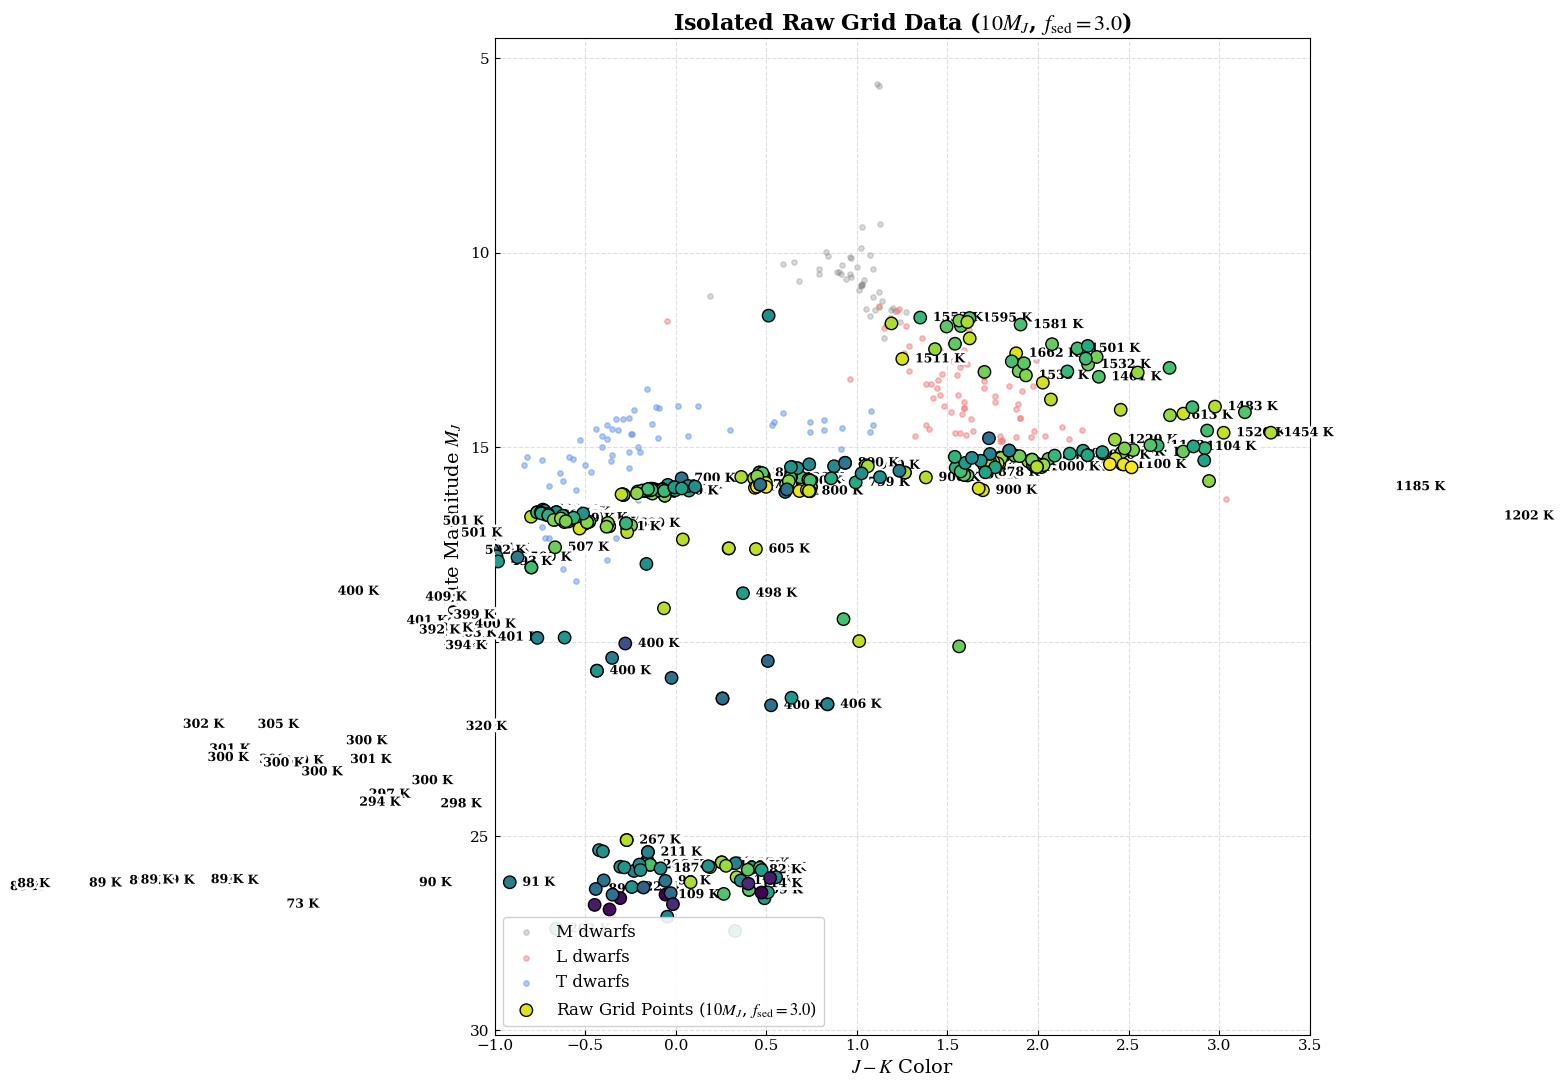

In [9]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =====================================================================
# CONSTANTS & SCALING
# =====================================================================
PC_10_M = 3.08567758e17
VEGA_J = 3.129e-9
VEGA_K = 4.3277e-10

print("--- 1. SCANNING RAW EXOREM HDF5 GRID ---")
h5_path = "../../exoweave/outputs/master_grid_data.h5"

df = df_grid[
    (np.abs(df_grid['T_irr'] - 100.0) <= 50.5) &
    (np.abs(df_grid['Met'] - 0.0) <= 0.5) &
    (np.abs(df_grid['core'] - 10.0) <= 5.0) &
    (np.abs(df_grid['f_sed_refractory'] - 3.0) < 1) &
    (np.abs(df_grid['f_sed_volatile'] - 3.0) < 1) &
    (np.abs(df_grid['kzz'] - 8.0) <= 1.0)
]

# Sort from hottest to coldest
df_raw = df.sort_values('T_int', ascending=False)
df_raw['radius_m'] = df_raw['Req_Rj'] * R_J_M
print(f"✅ Extracted {len(df_raw)} raw discrete 10 M_J models.")


# =====================================================================
# 2. CALCULATE ABSOLUTE MAGNITUDES DIRECTLY
# =====================================================================
# Scale factor = (Radius / 10 parsecs)^2
scale_factors = (df_raw['radius_m'] / PC_10_M)**2

df_raw['flux_10pc_j'] = 10**df_raw['log_Keck/NIRC2.J'] * scale_factors
df_raw['flux_10pc_k'] = 10**df_raw['log_Keck/NIRC2.Ks'] * scale_factors

df_raw['mag_J'] = -2.5 * np.log10(df_raw['flux_10pc_j'] / VEGA_J)
df_raw['mag_K'] = -2.5 * np.log10(df_raw['flux_10pc_k'] / VEGA_K)
df_raw['color_JK'] = df_raw['mag_J'] - df_raw['mag_K']

# =====================================================================
# 3. PLOTTING ROUTINE
# =====================================================================
# Load Background Data using your Cmd class
cmd_bg = Cmd(datapath='../CMD/data/') 
cmd_bg._dupuy() 

fig, ax = plt.subplots(figsize=(9, 11))

# Plot Background
ax.scatter(cmd_bg.MD['magJ'] - cmd_bg.MD['magK'], cmd_bg.MD['magJ'], color='gray', alpha=0.3, s=15, label='M dwarfs')
ax.scatter(cmd_bg.LD['magJ'] - cmd_bg.LD['magK'], cmd_bg.LD['magJ'], color='lightcoral', alpha=0.5, s=15, label='L dwarfs')
ax.scatter(cmd_bg.TD['magJ'] - cmd_bg.TD['magK'], cmd_bg.TD['magJ'], color='cornflowerblue', alpha=0.5, s=15, label='T dwarfs')

stroke = [pe.withStroke(linewidth=4, foreground='white')]

# Plot ONLY the disconnected scatter points
ax.scatter(df_raw['color_JK'], df_raw['mag_J'], c=np.log10(df_raw['mass_Mj']), s=80, edgecolor='black', 
           zorder=5, label=r'Raw Grid Points ($10 M_J$, $f_{\rm sed}=3.0$)')

# Annotate roughly every 3rd point so the plot doesn't get completely cluttered with text
for i, (idx, row) in enumerate(df_raw.iterrows()):
    if i % 3 == 0 or i == 0 or i == len(df_raw) - 1:
        ax.text(row['color_JK'] + 0.07, row['mag_J'], f"{row['T_int']:.0f} K", 
                fontsize=9, va='center', ha='left', fontweight='bold', path_effects=stroke)

# Final Formatting
ax.invert_yaxis() 
ax.set_xlabel(r'$J - K$ Color', fontsize=14)
ax.set_ylabel(r'Absolute Magnitude $M_J$', fontsize=14)
ax.set_title(r"Isolated Raw Grid Data ($10 M_J$, $f_{\rm sed}=3.0$)", fontsize=16, fontweight='bold')
ax.legend(loc='lower left', fontsize=12, framealpha=0.9)
ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.xlim(-1.0, 3.5) 
plt.savefig('../figures/cmd_raw_scatter_10Mj.pdf', dpi=300, bbox_inches='tight')
plt.show()

--- 1. DOWNLOADING KECK FILTERS ---


--- 2. EXTRACTING & INTEGRATING RAW SPECTRA ---
✅ Extracted and manually integrated 25 raw discrete 10 M_J models.


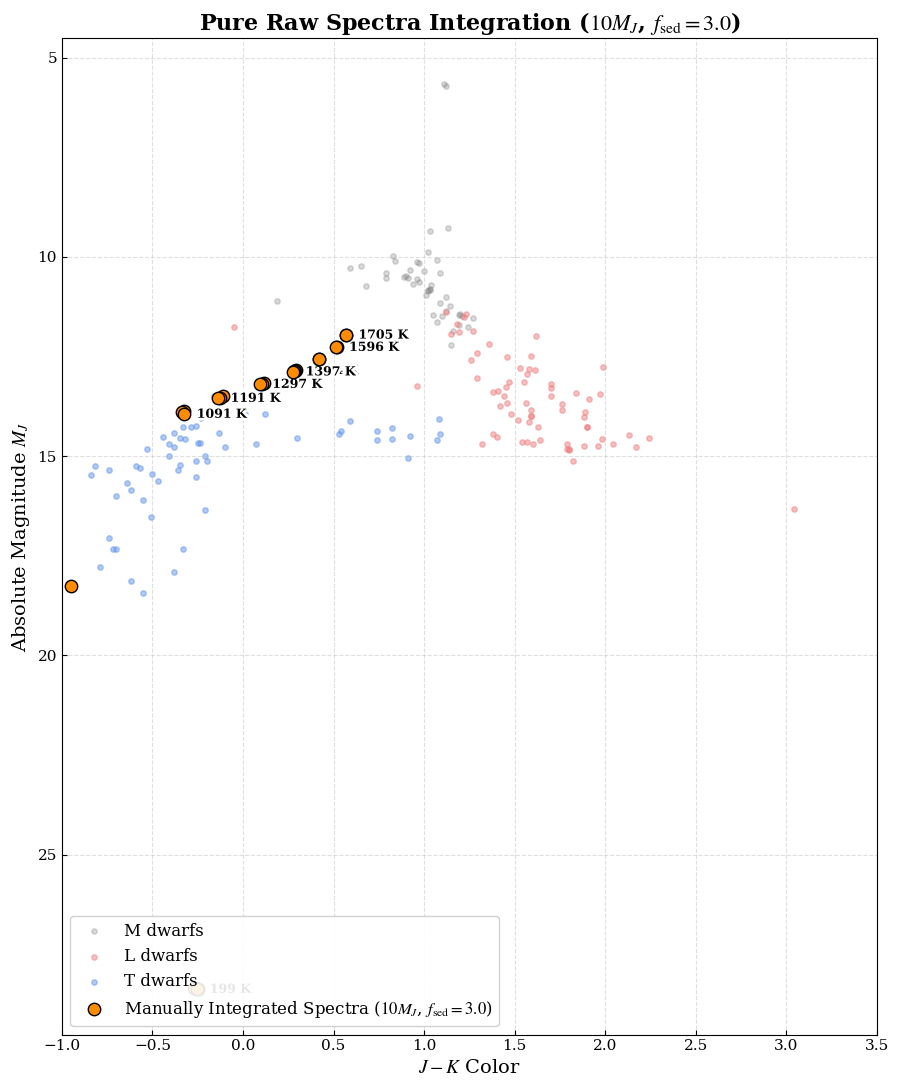

In [10]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import urllib.request
from io import StringIO

# =====================================================================
# CONSTANTS & SCALING
# =====================================================================
PC_10_M = 3.08567758e17
VEGA_J = 3.129e-9
VEGA_K = 4.3277e-10

print("--- 1. DOWNLOADING KECK FILTERS ---")
def get_filter(filter_id):
    url = f"https://svo2.cab.inta-csic.es/theory/fps/getdata.php?format=ascii&id={filter_id}"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    response = urllib.request.urlopen(req)
    parsed = np.genfromtxt(StringIO(response.read().decode('utf-8')))
    return parsed[:, 0] * 1e-4, parsed[:, 1] # microns, transmission

wav_j, trans_j = get_filter("Keck/NIRC2.J")
wav_k, trans_k = get_filter("Keck/NIRC2.Ks")

def integrate_band(filt_wav, filt_trans, exo_wl, exo_flux):
    """Manually integrates the raw spectrum through the filter"""
    interp_trans = np.interp(exo_wl, filt_wav, filt_trans, left=0.0, right=0.0)
    num = np.trapezoid(exo_flux * interp_trans * exo_wl, exo_wl)
    den = np.trapezoid(interp_trans * exo_wl, exo_wl)
    return num / den

print("--- 2. EXTRACTING & INTEGRATING RAW SPECTRA ---")
h5_path = "../../exoweave/outputs/master_grid_cloudless_data.h5"  # Adjust if needed!

raw_data = []

with h5py.File(h5_path, "r") as f:
    for m_id in f.keys():
        params = f[m_id]['parameters'].attrs
        
        mass_dial = params.get('mass', 0.0)
        tint = params.get('T_int', 0.0)
        fsed = params.get('f_sed', 0.0)
        tirr = params.get('T_irr', 0.0)
        met = params.get('Met', -99.0)
        core = params.get('core_mass_earth', 0.0)
        
        # --- STRICTLY FILTER FOR 10 M_J AND F_SED = 3.0 ---
        if np.isclose(mass_dial, 10.0, atol=0.5) and fsed == 3.0 and tirr <= 101.0 and met == 0.0 and core == 10.0:
            try:
                # 1. Extract COMPLETELY RAW Fortran Arrays
                rad = f[m_id]['atmosphere_raw']['_outputs_spectra_emission_spectral_radiosity'][()]
                wn = f[m_id]['atmosphere_raw']['_outputs_spectra_wavenumber'][()]
                radius_m = f[m_id]['interior_raw'].attrs['R_total']
                
                # 2. JACOBIAN CONVERSION
                valid = wn > 0
                rad_clean, wn_clean = rad[valid], wn[valid]
                wl = 10000.0 / wn_clean
                flam = rad_clean * 1e-4 * (wn_clean**2)
                
                # Sort by wavelength
                idx = np.argsort(wl)
                wl, flam = wl[idx], flam[idx]
                
                # 3. MANUAL INTEGRATION
                calc_j_flux = integrate_band(wav_j, trans_j, wl, flam)
                calc_k_flux = integrate_band(wav_k, trans_k, wl, flam)
                
                raw_data.append({
                    'T_int': tint,
                    'flux_j': calc_j_flux,
                    'flux_k': calc_k_flux,
                    'radius_m': radius_m
                })
            except KeyError:
                continue

df_raw = pd.DataFrame(raw_data)
df_raw = df_raw.sort_values('T_int', ascending=False)
print(f"✅ Extracted and manually integrated {len(df_raw)} raw discrete 10 M_J models.")

# =====================================================================
# 3. CALCULATE ABSOLUTE MAGNITUDES DIRECTLY
# =====================================================================
# Scale factor = (Radius / 10 parsecs)^2
scale_factors = (df_raw['radius_m'] / PC_10_M)**2

df_raw['flux_10pc_j'] = df_raw['flux_j'] * scale_factors
df_raw['flux_10pc_k'] = df_raw['flux_k'] * scale_factors

df_raw['mag_J'] = -2.5 * np.log10(df_raw['flux_10pc_j'] / VEGA_J)
df_raw['mag_K'] = -2.5 * np.log10(df_raw['flux_10pc_k'] / VEGA_K)
df_raw['color_JK'] = df_raw['mag_J'] - df_raw['mag_K']

# =====================================================================
# 4. PLOTTING ROUTINE
# =====================================================================
# Load Background Data using your Cmd class
cmd_bg = Cmd(datapath='../CMD/data/') 
cmd_bg._dupuy() 

fig, ax = plt.subplots(figsize=(9, 11))

# Plot Background
ax.scatter(cmd_bg.MD['magJ'] - cmd_bg.MD['magK'], cmd_bg.MD['magJ'], color='gray', alpha=0.3, s=15, label='M dwarfs')
ax.scatter(cmd_bg.LD['magJ'] - cmd_bg.LD['magK'], cmd_bg.LD['magJ'], color='lightcoral', alpha=0.5, s=15, label='L dwarfs')
ax.scatter(cmd_bg.TD['magJ'] - cmd_bg.TD['magK'], cmd_bg.TD['magJ'], color='cornflowerblue', alpha=0.5, s=15, label='T dwarfs')

stroke = [pe.withStroke(linewidth=4, foreground='white')]

# Plot ONLY the disconnected scatter points derived from raw spectra
ax.scatter(df_raw['color_JK'], df_raw['mag_J'], color='darkorange', s=80, edgecolor='black', 
           zorder=5, label=r'Manually Integrated Spectra ($10 M_J$, $f_{\rm sed}=3.0$)')

# Annotate roughly every 3rd point so the plot doesn't get completely cluttered with text
for i, (idx, row) in enumerate(df_raw.iterrows()):
    if i % 3 == 0 or i == 0 or i == len(df_raw) - 1:
        ax.text(row['color_JK'] + 0.07, row['mag_J'], f"{row['T_int']:.0f} K", 
                fontsize=9, va='center', ha='left', fontweight='bold', path_effects=stroke)

# Final Formatting
ax.invert_yaxis() 
ax.set_xlabel(r'$J - K$ Color', fontsize=14)
ax.set_ylabel(r'Absolute Magnitude $M_J$', fontsize=14)
ax.set_title(r"Pure Raw Spectra Integration ($10 M_J$, $f_{\rm sed}=3.0$)", fontsize=16, fontweight='bold')
ax.legend(loc='lower left', fontsize=12, framealpha=0.9)
ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.xlim(-1.0, 3.5) 
plt.savefig('../figures/cmd_manual_integration_10Mj.pdf', dpi=300, bbox_inches='tight')
plt.show()